In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.sqlite_version}")

All libraries imported successfully!
pandas version:2.2.2
sqlite3 version:3.37.2


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Data engg and genai internship/student_performance.csv')

print(f"Dataset loaded:{df.shape[0]}students,{df.shape[1]}columns")
print(f"columns:{df.columns.tolist()}")

df.head(3)

Dataset loaded:30students,13columns
columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [ ]:
print(df.shape[1])   #column(field)
print(df.shape[0])   #row(record)

13
30


In [ ]:
conn=sqlite3.connect('college.db')

cursor=conn.cursor()

df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False    #do not write dataframe row number as a column

)

cursor.execute("select count(*) from students")
count=cursor.fetchone()[0]

print(f"Database 'college.db' created successfully!")
print(f"Table 'students' has {count} rows")

Database 'college.db' created successfully!
Table 'students' has 30 rows


In [ ]:
cursor.execute("PRAGMA table_info(students)")
columns_info = cursor.fetchall()

print("Table structure of 'students':\n")
print(f"{'Column Name':25}{'Data Types':<12}")
print("_"*38)
for col in columns_info:
  print(f"{col[1]:25}{col[2]:<12}")

Table structure of 'students':

Column Name              Data Types  
______________________________________
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


In [ ]:
def run_query(sql,description=""):
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"{'='*55}")
  result = pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result

In [ ]:
query1="""
  SELECT student_id, name, department, math_score, attendance_percentage
  FROM students
  LIMIT 10
"""
result=pd.read_sql_query(query1,conn)
result

,student_id,name,department,math_score,attendance_percentage
0,1001,Aarav Sharma,Computer Science,85,92
1,1002,Priya Patel,Computer Science,76,87
2,1003,Rohit Verma,Electronics,65,78
3,1004,Sneha Reddy,Mechanical,70,95
4,1005,Arjun Nair,Computer Science,92,90
5,1006,Meera Joshi,Electronics,58,72
6,1007,Kiran Kumar,Civil,73,85
7,1008,Divya Singh,Computer Science,88,96
8,1009,Rahul Mishra,Mechanical,62,68
9,1010,Ananya Das,Computer Science,95,98


In [ ]:
result1= run_query(query1,"Top 10 students(SELECT + LIMIT)")


Top 10 students(SELECT + LIMIT)
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [ ]:
query2="""
  SELECT student_id, name, department, math_score, attendance_percentage
  FROM students
  LIMIT 5 offset 25
"""
result2= run_query(query2,"Top 10 students(SELECT + LIMIT)")


Top 10 students(SELECT + LIMIT)
 student_id           name       department  math_score  attendance_percentage
       1026     Rekha Nair      Electronics          72                     82
       1027  Gaurav Shukla Computer Science          84                     87
       1028  Sunita Pillai            Civil          60                     73
       1029     Nitin Jain       Mechanical          75                     84
       1030 Akanksha Yadav Computer Science          91                     95


In [ ]:
query3="""
  SELECT name, department, math_score
  FROM students
  order by math_score desc
  LIMIT 5
"""
result=pd.read_sql_query(query3,conn)
result

,name,department,math_score
0,Ananya Das,Computer Science,95
1,Tanvi Mehta,Computer Science,93
2,Arjun Nair,Computer Science,92
3,Akanksha Yadav,Computer Science,91
4,Swati Kulkarni,Computer Science,90


In [ ]:
query4="""
  SELECT name, department, programming_score
  FROM students
  where programming_score between 50 and 70
  order by programming_score asc
"""
result4=run_query(query4,"top 10 students")


top 10 students
         name  department  programming_score
   Nitin Jain  Mechanical                 50
Kavya Nambiar  Mechanical                 51
  Meera Joshi Electronics                 52
Preeti Saxena  Mechanical                 53
  Rohit Verma Electronics                 55
Harish Pillai Electronics                 58
   Rekha Nair Electronics                 63
 Ritu Agarwal Electronics                 69


In [ ]:
query5="""
  SELECT name,math_score,science_score, programming_score, attendance_percentage
  FROM students
  where department='Computer Science'
  order by programming_score desc
"""
result5=run_query(query5,"top 10 students")


top 10 students
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor          79             84                 8

In [ ]:
query6="""
  SELECT distinct department
  FROM students
  limit 3
"""
query7="""
  select name,department,programmingsv_score
  from students
  order by programming_score desc
  limit 1
"""
result6=run_query(query7,"Department")


Department
      name       department  programming_score
Ananya Das Computer Science                 97


In [ ]:
query8="""
    select name,department,attendance_percentage
    from students
    where attendance_percentage>90
    and department!='Civil'
    order by attendance_percentage desc
"""
result8=run_query(query8,"exclude")


exclude
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


In [ ]:
query9="""
    select name,department,attendance_percentage
    from students
    where department!=(attendance_percentage>=80)
    order by attendance_percentage asc
"""
result8=run_query(query9,"exclude")


exclude
          name       department  attendance_percentage
  Manoj Pandey            Civil                     65
  Rahul Mishra       Mechanical                     68
  Sanjay Dubey            Civil                     70
   Meera Joshi      Electronics                     72
 Sunita Pillai            Civil                     73
 Harish Pillai      Electronics                     74
   Ajay Tiwari Computer Science                     75
Deepak Chauhan       Mechanical                     77
   Rohit Verma      Electronics                     78
   Pooja Gupta            Civil                     80
    Rekha Nair      Electronics                     82
   Vikram Iyer      Electronics                     83
    Nitin Jain       Mechanical                     84
   Kiran Kumar            Civil                     85
 Preeti Saxena       Mechanical                     86
   Priya Patel Computer Science                     87
 Gaurav Shukla Computer Science                     87
 

In [ ]:
dept_data={
    'dept_code':['CS','EC','ME','CE'],
    'dept_name':['Computer Science','Electronics','Mechanical','Civil'],
    'hod_name':['Dr Sharma','Dr Reddy','Dr Patel','Dr Kumar'],
    'established':[1985,1988,1972,1965],
    'intake':[60,60,60,60]
}
dept_df=pd.DataFrame(dept_data)
dept_df

dept_df.to_sql('departments',conn,if_exists='replace',index=False)

print("Created 'departments'table:")
print(dept_df.to_string(index=False))

dept_map = {
    'Computer Science': 'CS',
    'Electronics': 'EC',
    'Mechanical': 'ME',
    'Civil': 'CE'
}

# Map the department names in the students DataFrame to department codes
df['dept_code'] = df['department'].map(dept_map)

# Re-create the departments table with the dept_code (already done above, but good to ensure)
dept_df.to_sql('departments', conn, if_exists='replace', index=False)

# Re-create the students table with the new dept_code column
df.to_sql('students', conn, if_exists='replace', index=False)

print("\nUpdated 'students' table:")
print(df.to_string(index=False))

Created 'departments'table:
dept_code        dept_name  hod_name  established  intake
       CS Computer Science Dr Sharma         1985      60
       EC      Electronics  Dr Reddy         1988      60
       ME       Mechanical  Dr Patel         1972      60
       CE            Civil  Dr Kumar         1965      60

Updated 'students' table:
 student_id           name  age gender       department  semester  math_score  science_score  english_score  programming_score  attendance_percentage               city  admission_year dept_code
       1001   Aarav Sharma   19   Male Computer Science         2          85             78             72                 91                     92             Mumbai            2023        CS
       1002    Priya Patel   20 Female Computer Science         2          76             82             88                 79                     87          Ahmedabad            2023        CS
       1003    Rohit Verma   19   Male      Electronics         2     

In [ ]:
query_join="""
select s.name,
s.math_score,
d.dept_name,
d.intake,
d.established
from students AS s
inner join departments as d
on s.dept_code=d.dept_code
order by s.math_score DESC
limit 8
"""
result1=run_query(query_join,"query 13:(select+innerjoin+orderby)")


query 13:(select+innerjoin+orderby)
          name  math_score        dept_name  intake  established
    Ananya Das          95 Computer Science      60         1985
   Tanvi Mehta          93 Computer Science      60         1985
    Arjun Nair          92 Computer Science      60         1985
Akanksha Yadav          91 Computer Science      60         1985
Swati Kulkarni          90 Computer Science      60         1985
   Divya Singh          88 Computer Science      60         1985
  Ritu Agarwal          87      Electronics      60         1988
     Amit Bose          86 Computer Science      60         1985


fig,ax=plt.subplot(figsize=(width,height))
ax.bar(x,y)
ax.set_title('...')
ax.set_xlabel('...')
ax.set_ylabel('...')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Average Math Score')

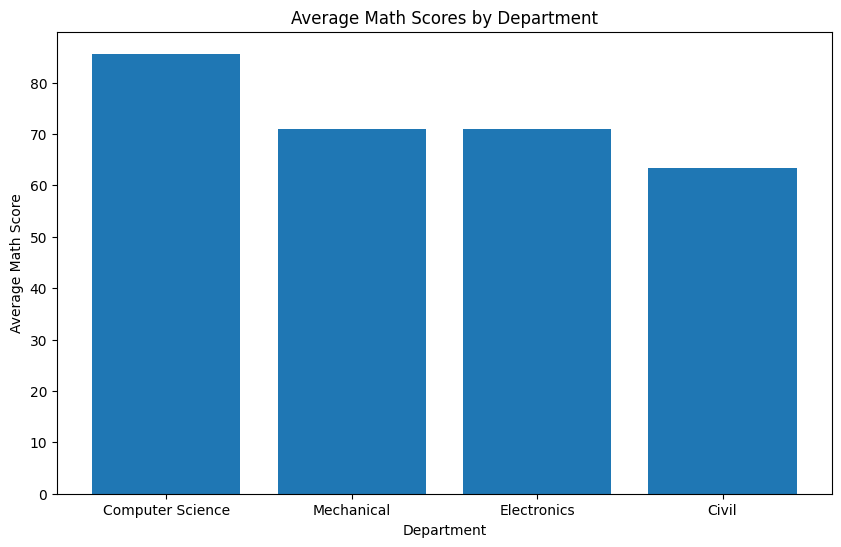

In [ ]:
chart1_sql="""
   select department,round(avg(math_score),2)as avg_math
   from students
   group by department
   order by avg_math desc
"""
chart1_data=pd.read_sql_query(chart1_sql,conn)

fig,ax=plt.subplots(figsize=(10,6))
ax.bar(chart1_data['department'],chart1_data['avg_math'])
ax.set_title('Average Math Scores by Department')
ax.set_xlabel('Department')
ax.set_ylabel('Average Math Score')